In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print("✅ Librairies chargées !")

✅ Librairies chargées !


In [4]:
df  = pd.read_csv('data/processed/online_retail_clean.csv',
                  parse_dates=['InvoiceDate'])
rfm = pd.read_csv('data/processed/rfm_segments.csv')

print(f"✅ Transactions : {len(df):,} lignes")
print(f"✅ Clients RFM  : {len(rfm):,} clients")
print()
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
 'Segment']].head()

✅ Transactions : 392,692 lignes
✅ Clients RFM  : 4,338 clients



,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,326,1,77183.600,Clients Ordinaires
1,12347,2,7,4310.000,Champions
2,12348,75,4,1797.240,Clients Endormis
3,12349,19,1,1757.550,Nouveaux Clients
4,12350,310,1,334.400,Clients Perdus


In [5]:
rfm['Segment'].unique()

array(['Clients Ordinaires', 'Champions', 'Clients Endormis',
       'Nouveaux Clients', 'Clients Perdus', 'Clients Fidèles',
       'Clients Potentiels'], dtype=object)

 Créer la variable cible

In [6]:
# Seuil churn = 90 jours sans achat
CHURN_THRESHOLD = 90

rfm['Churn'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

total    = len(rfm)
churned  = rfm['Churn'].sum()
active   = total - churned

print(f"Clients totaux   : {total:,}")
print(f"Clients churné   : {churned:,} ({churned/total*100:.1f}%)")
print(f"Clients actifs   : {active:,} ({active/total*100:.1f}%)")

Clients totaux   : 4,338
Clients churné   : 1,449 (33.4%)
Clients actifs   : 2,889 (66.6%)


Visualiser la distribution du churn

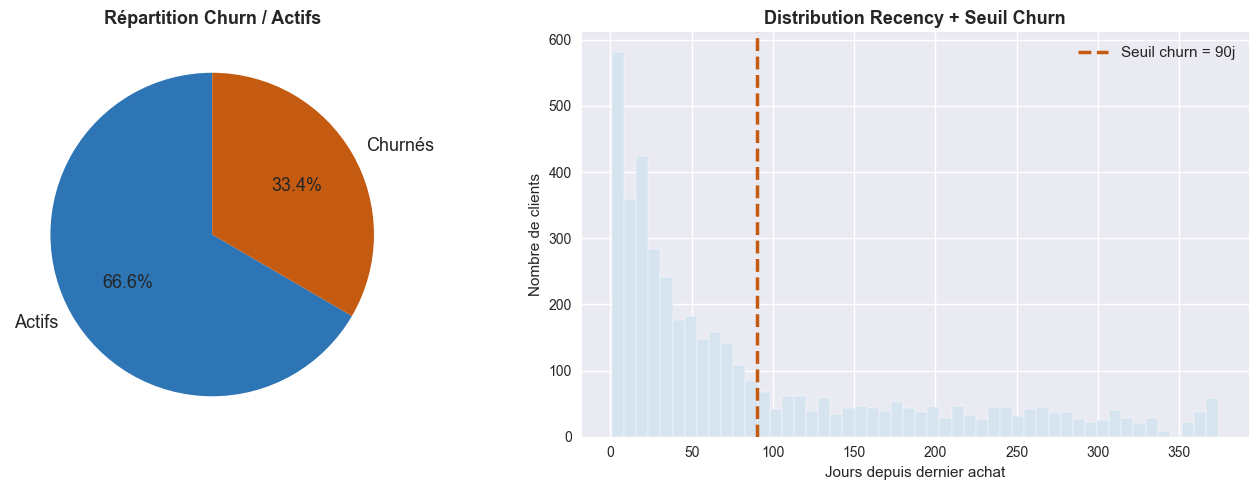

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Camembert
axes[0].pie([active, churned],
            labels=['Actifs', 'Churnés'],
            colors=['#2E75B6', '#C55A11'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13})
axes[0].set_title('Répartition Churn / Actifs',
                  fontsize=13, fontweight='bold')

# Distribution Recency avec seuil
axes[1].hist(rfm['Recency'], bins=50,
             color='#D6E4F0', edgecolor='white')
axes[1].axvline(x=CHURN_THRESHOLD, color='#C55A11',
                linewidth=2.5, linestyle='--',
                label=f'Seuil churn = {CHURN_THRESHOLD}j')
axes[1].set_title('Distribution Recency + Seuil Churn',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jours depuis dernier achat')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
churn_by_segment = rfm.groupby('Segment')['Churn'].agg(
    Total='count',
    Churned='sum'
)
churn_by_segment['Taux_Churn_%'] = (
    churn_by_segment['Churned'] /
    churn_by_segment['Total'] * 100
).round(1)


print("TAUX DE CHURN PAR SEGMENT")
print(churn_by_segment.sort_values('Taux_Churn_%',
      ascending=False).to_string())

TAUX DE CHURN PAR SEGMENT
                    Total  Churned  Taux_Churn_%
Segment                                         
Clients Perdus       1059      962        90.800
Clients Endormis      453      342        75.500
Clients Ordinaires    657      145        22.100
Clients Fidèles       763        0         0.000
Champions             957        0         0.000
Clients Potentiels    130        0         0.000
Nouveaux Clients      319        0         0.000


# Feature Engineering

In [9]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

features = df.groupby('CustomerID').agg(
    Recency        = ('InvoiceDate',
                      lambda x: (reference_date - x.max()).days),
    Frequency      = ('InvoiceNo',   'nunique'),
    Monetary       = ('TotalPrice',  'sum'),
    Avg_OrderValue = ('TotalPrice',  'mean'),
    Nb_Produits    = ('StockCode',   'nunique'),
    Avg_Quantity   = ('Quantity',    'mean'),
    Nb_Jours_Actif = ('InvoiceDate',
                      lambda x: (x.max() - x.min()).days),
    Total_Items    = ('Quantity',    'sum'),
).reset_index()

features = features.merge(
    rfm[['CustomerID', 'Churn', 'Segment']],
    on='CustomerID', how='left'
)

print(f"Features construites : {features.shape[1]-2} variables")
print(f"   Clients              : {len(features):,}")
print()
for col in features.columns[1:]:
    print(f"  → {col}")

Features construites : 9 variables
   Clients              : 4,338

  → Recency
  → Frequency
  → Monetary
  → Avg_OrderValue
  → Nb_Produits
  → Avg_Quantity
  → Nb_Jours_Actif
  → Total_Items
  → Churn
  → Segment


Features supplémentaires

In [10]:
features['Cadence'] = features['Frequency'] / (
    features['Nb_Jours_Actif'] + 1
)

features['Panier_Moyen'] = (
    features['Monetary'] / features['Frequency']
)
print(f"\nTotal features : {features.shape[1] - 3}")


Total features : 10


Vérification

In [11]:
print("APERÇU DES FEATURES")
print(features.describe().round(2))
print()
print(f"Valeurs manquantes : {features.isnull().sum().sum()}")

APERÇU DES FEATURES
       CustomerID  Recency  Frequency   Monetary  Avg_OrderValue  Nb_Produits  \
count    4338.000 4338.000   4338.000   4338.000        4338.000     4338.000   
mean    15300.410   92.540      4.270   2048.690          68.380       61.500   
std      1721.810  100.010      7.700   8985.230        1467.920       85.370   
min     12346.000    1.000      1.000      3.750           2.140        1.000   
25%     13813.250   18.000      1.000    306.480          12.390       16.000   
50%     15299.500   51.000      2.000    668.570          17.760       35.000   
75%     16778.750  142.000      5.000   1660.600          24.880       77.000   
max     18287.000  374.000    209.000 280206.020       77183.600     1787.000   

       Avg_Quantity  Nb_Jours_Actif  Total_Items    Churn  Cadence  \
count      4338.000        4338.000     4338.000 4338.000 4338.000   
mean         45.080         130.450     1187.640    0.330    0.410   
std        1203.440         132.040     

In [15]:
features['Churn']

0       1
1       0
2       0
3       0
4       1
       ..
4333    1
4334    1
4335    0
4336    0
4337    0
Name: Churn, Length: 4338, dtype: int64

In [13]:

FEATURE_COLS = [
    'Frequency', 'Monetary', 'Avg_OrderValue',
    'Nb_Produits', 'Avg_Quantity', 'Nb_Jours_Actif',
    'Total_Items', 'Cadence', 'Panier_Moyen'
]

X = features[FEATURE_COLS]
y = features['Churn']

print(f"Features utilisées : {len(FEATURE_COLS)}")
print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"   Taux churn : {y.mean()*100:.1f}%")

Features utilisées : 9
   X shape : (4338, 9)
   y shape : (4338,)
   Taux churn : 33.4%


Train/Test Split

In [17]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   Train : {len(X_train):,} clients ({y_train.mean()*100:.1f}% churn)")
print(f"   Test  : {len(X_test):,} clients ({y_test.mean()*100:.1f}% churn)")

   Train : 3,470 clients (33.4% churn)
   Test  : 868 clients (33.4% churn)


Logistic Regression (baseline)

In [18]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr,
      target_names=['Actif', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

       Actif       0.83      0.80      0.81       578
      Churné       0.63      0.66      0.64       290

    accuracy                           0.76       868
   macro avg       0.73      0.73      0.73       868
weighted avg       0.76      0.76      0.76       868

AUC-ROC : 0.8159


 Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf,
      target_names=['Actif', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

       Actif       0.80      0.83      0.81       578
      Churné       0.63      0.58      0.60       290

    accuracy                           0.75       868
   macro avg       0.71      0.70      0.71       868
weighted avg       0.74      0.75      0.74       868

AUC-ROC : 0.8244


XGBoost

In [21]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


print("XGBOOST")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Actif', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBOOST
              precision    recall  f1-score   support

       Actif       0.78      0.81      0.80       578
      Churné       0.59      0.54      0.57       290

    accuracy                           0.72       868
   macro avg       0.69      0.68      0.68       868
weighted avg       0.72      0.72      0.72       868

AUC-ROC : 0.8060


In [25]:
results = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    'F1-Churné': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'Accuracy': [
        (y_pred_lr == y_test).mean(),
        (y_pred_rf == y_test).mean(),
        (y_pred_xgb == y_test).mean()
    ]
}).round(4)

print("COMPARAISON FINALE DES MODÈLES")
print(results.to_string(index=False))

COMPARAISON FINALE DES MODÈLES
             Modèle  AUC-ROC  F1-Churné  Accuracy
Logistic Regression    0.816      0.644     0.756
      Random Forest    0.824      0.602     0.745
            XGBoost    0.806      0.567     0.722


Courbes ROC

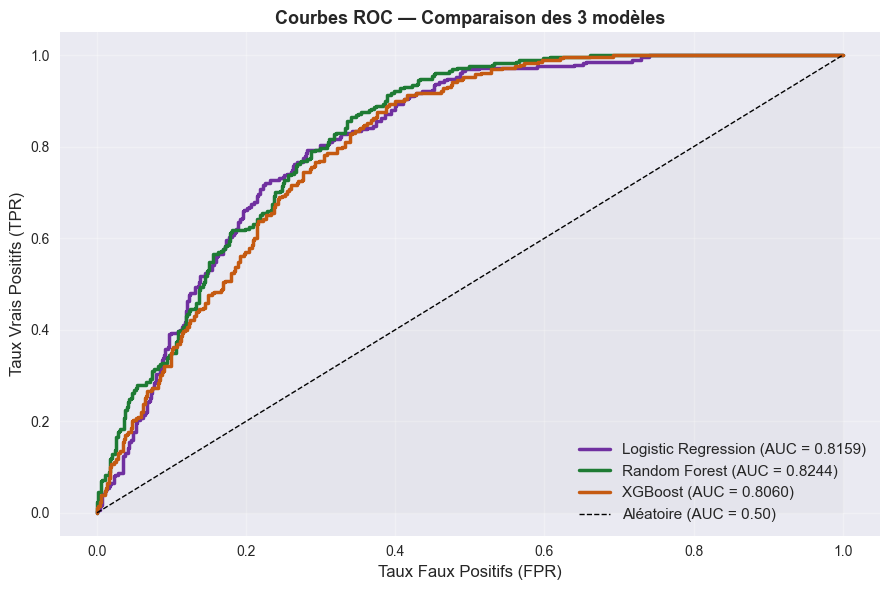

In [26]:
plt.figure(figsize=(9, 6))

for name, proba, color in [
    ('Logistic Regression', y_proba_lr, '#7030A0'),
    ('Random Forest',       y_proba_rf, '#1E7B34'),
    ('XGBoost',             y_proba_xgb, '#C55A11')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2.5, color=color,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.50)')
plt.fill_between([0,1], [0,1], alpha=0.05, color='gray')
plt.xlabel('Taux Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC — Comparaison des 3 modèles',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

Matrice de confusion Random Forest

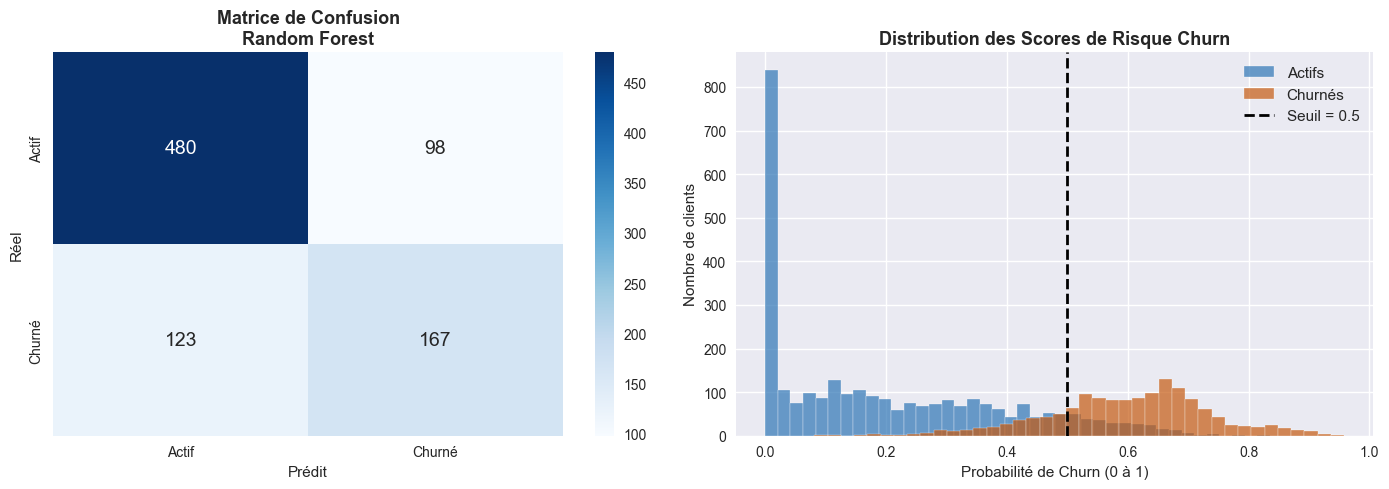

Score de risque churn ajouté pour chaque client
   Clients à haut risque (>70%) : 320
   Clients à risque moyen (50-70%) : 1,112
   Clients à faible risque (<50%) : 2,906


In [28]:
cm = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Actif', 'Churné'],
            yticklabels=['Actif', 'Churné'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Matrice de Confusion\nRandom Forest',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Score de risque churn (probabilité)
features['Churn_Score'] = rf.predict_proba(X)[:, 1]

axes[1].hist(features[features['Churn']==0]['Churn_Score'],
             bins=40, alpha=0.7, color='#2E75B6',
             label='Actifs', edgecolor='white')
axes[1].hist(features[features['Churn']==1]['Churn_Score'],
             bins=40, alpha=0.7, color='#C55A11',
             label='Churnés', edgecolor='white')
axes[1].axvline(x=0.5, color='black', linestyle='--',
                linewidth=2, label='Seuil = 0.5')
axes[1].set_title('Distribution des Scores de Risque Churn',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Probabilité de Churn (0 à 1)')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('reports/figures/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Score de risque churn ajouté pour chaque client")
print(f"   Clients à haut risque (>70%) : "
      f"{(features['Churn_Score'] > 0.7).sum():,}")
print(f"   Clients à risque moyen (50-70%) : "
      f"{((features['Churn_Score'] > 0.5) & (features['Churn_Score'] <= 0.7)).sum():,}")
print(f"   Clients à faible risque (<50%) : "
      f"{(features['Churn_Score'] < 0.5).sum():,}")

In [30]:
import joblib

# Sauvegarder les modèles 
joblib.dump(rf,        'models/random_forest_churn.pkl')
joblib.dump(xgb_model, 'models/xgboost_churn.pkl')
joblib.dump(lr,        'models/logistic_regression_churn.pkl')

# Sauvegarder le dataset avec scores de churn
features.to_csv('data/processed/features_churn.csv', index=False)